In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import gaussian_kde
from scipy.integrate import quad
from tqdm import tqdm
plt.style.use(['science','no-latex'])

colors = ["#1982c4", "black", "#ff595e", "#20b806"]

Read data

In [4]:
seeds = np.arange(4)
ntrajs = 2500
nsteps = 2000
traj_intxp3 =  np.zeros((nsteps,len(seeds),ntrajs,3))
traj_intxm3 =  np.zeros((nsteps,len(seeds),ntrajs,3))
traj_intyp3 =  np.zeros((nsteps,len(seeds),ntrajs,3))
traj_intym3 =  np.zeros((nsteps,len(seeds),ntrajs,3))
#traj_inty12 =  np.zeros((nsteps,len(seeds),ntrajs,2))
dir_noint = "/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_with_z_fast_int/pickles_traj"
dirx = "/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_with_z_fast_int/pickles_traj_intx"
diry = "/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_with_z_fast_int/pickles_traj_inty"
for seed in seeds:

    # intervention on x
    with open(f"{dirx}/intvalue3.0_seed{seed}_N2500_dt0.01_samplingdt1_nsteps2000_frictx1_fricty0.1_frictz0.1_temp1.p","rb") as f:
        traj_intxp3[:,seed] = pickle.load(f)
    with open(f"{dirx}/intvalue-3.0_seed{seed}_N2500_dt0.01_samplingdt1_nsteps2000_frictx1_fricty0.1_frictz0.1_temp1.p","rb") as f:
        traj_intxm3[:,seed] = pickle.load(f)

    # intervention on y
    with open(f"{diry}/intvalue3.0_seed{seed}_N2500_dt0.01_samplingdt1_nsteps2000_frictx1_fricty0.1_frictz0.1_temp1.p","rb") as f:
        traj_intyp3[:,seed] = pickle.load(f)
    with open(f"{diry}/intvalue-3.0_seed{seed}_N2500_dt0.01_samplingdt1_nsteps2000_frictx1_fricty0.1_frictz0.1_temp1.p","rb") as f:
        traj_intym3[:,seed] = pickle.load(f)

traj_intxp3 = traj_intxp3.reshape((nsteps,len(seeds)*ntrajs,3))
traj_intxm3 = traj_intxm3.reshape((nsteps,len(seeds)*ntrajs,3))
traj_intyp3 = traj_intyp3.reshape((nsteps,len(seeds)*ntrajs,3))
traj_intym3 = traj_intym3.reshape((nsteps,len(seeds)*ntrajs,3))

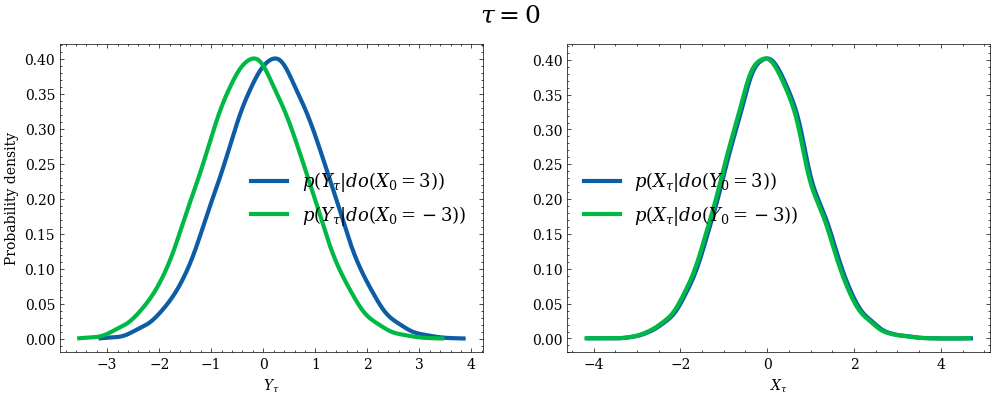

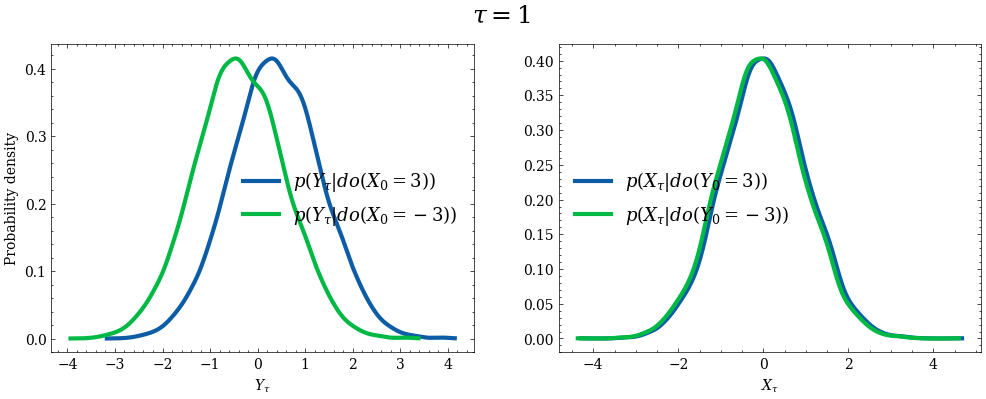

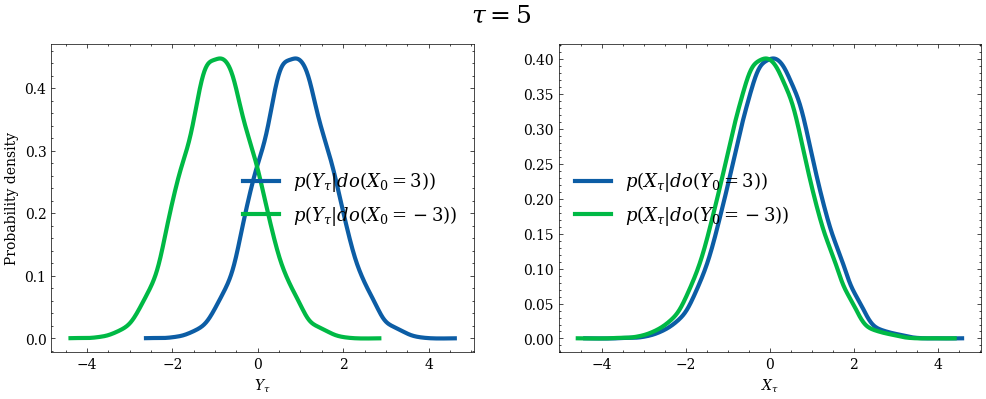

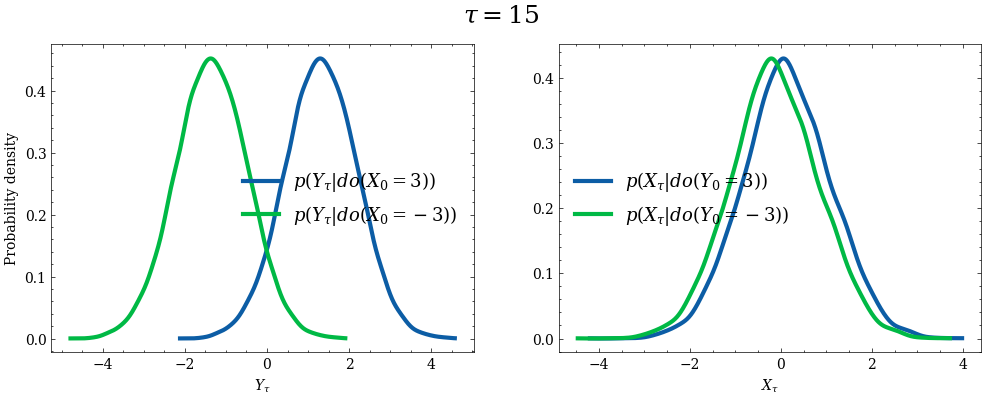

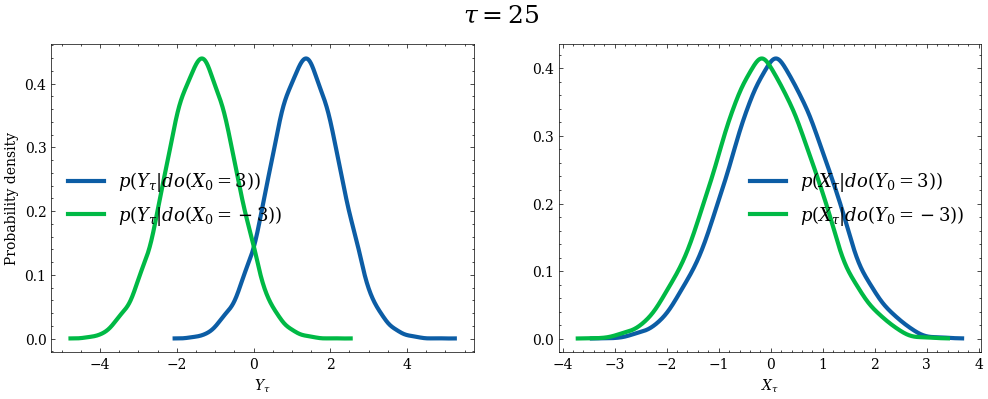

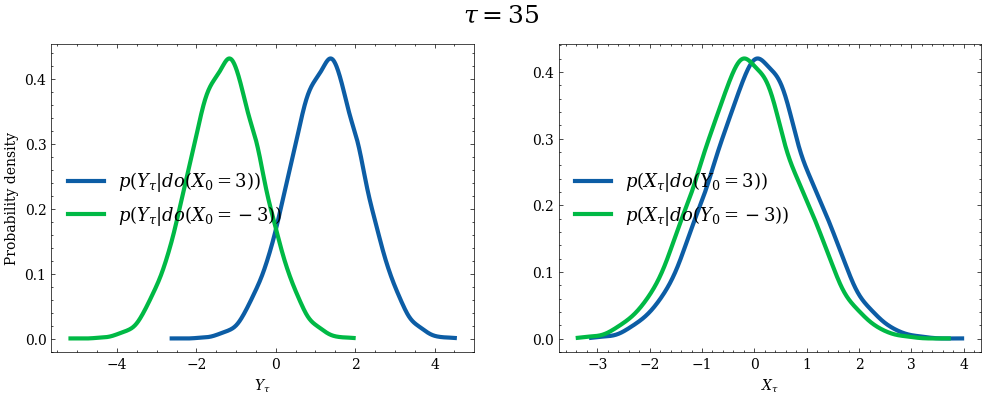

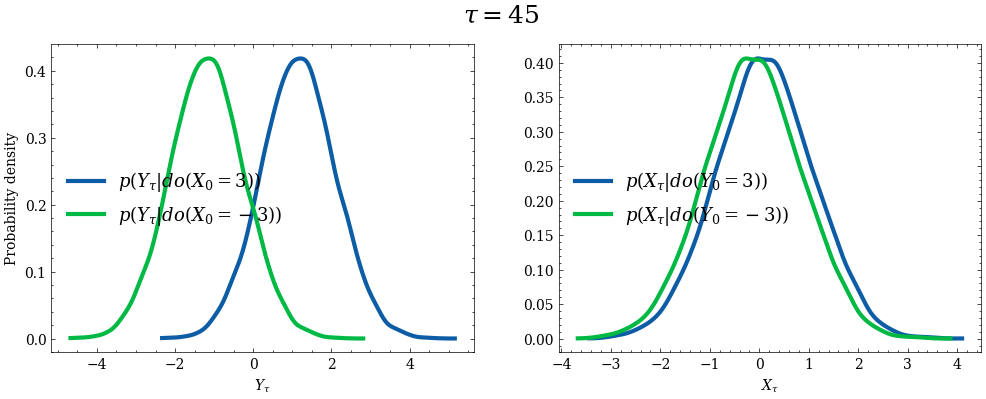

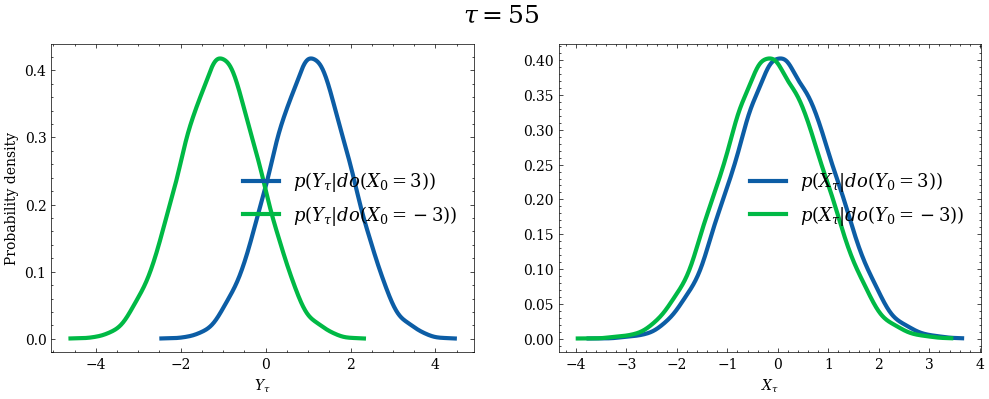

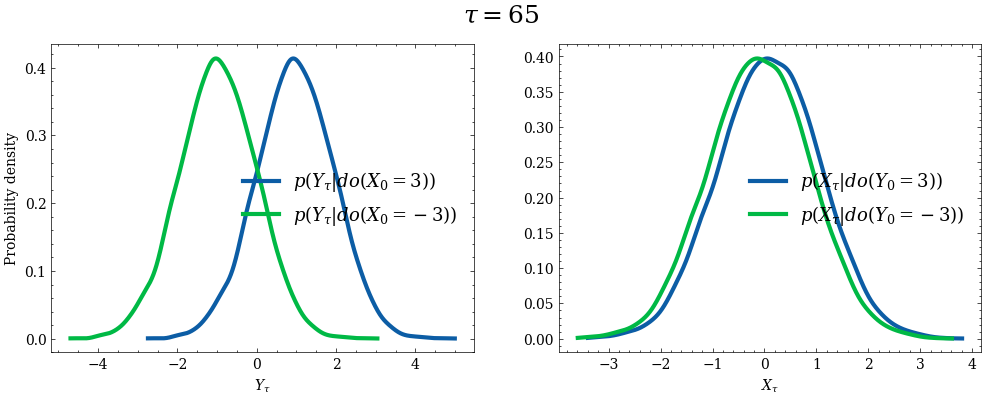

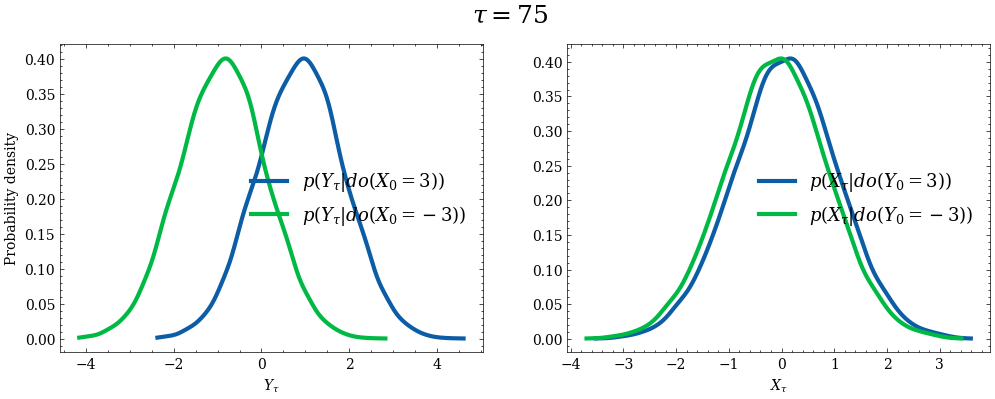

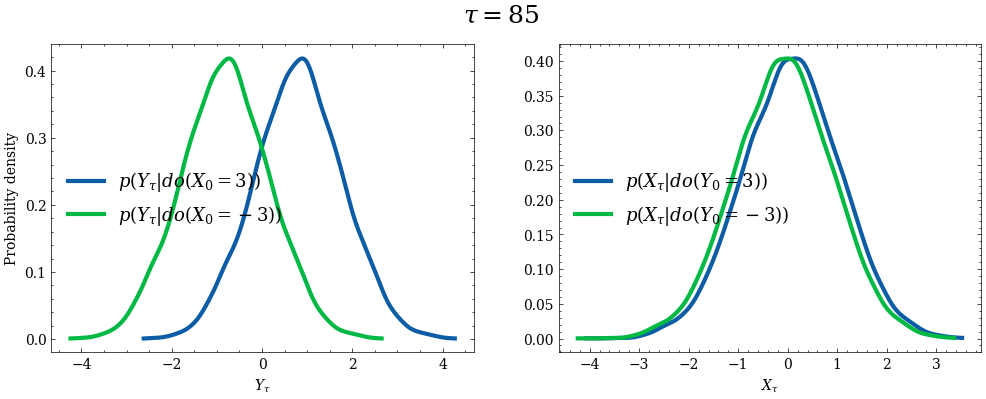

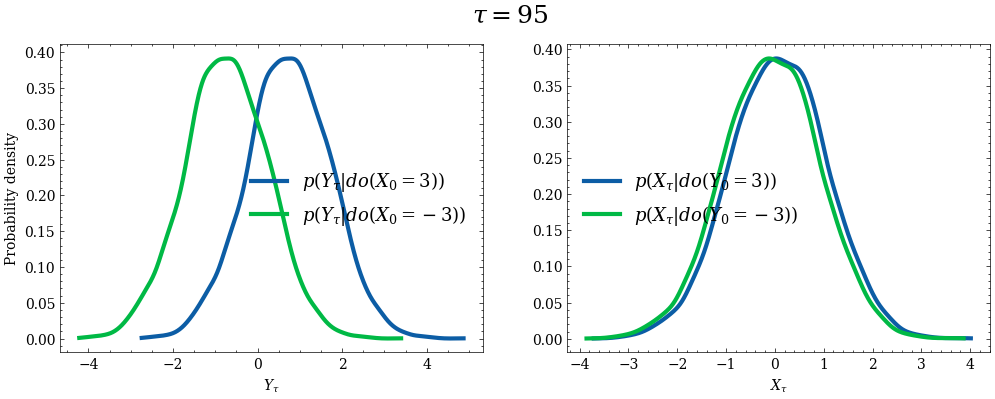

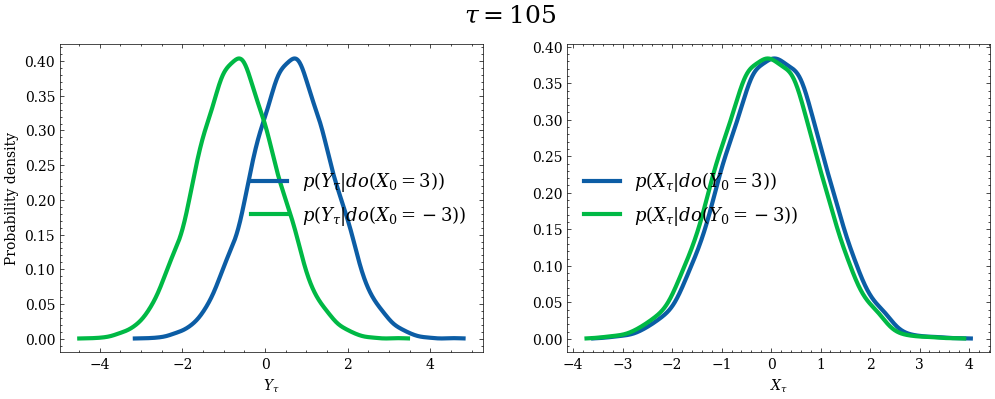

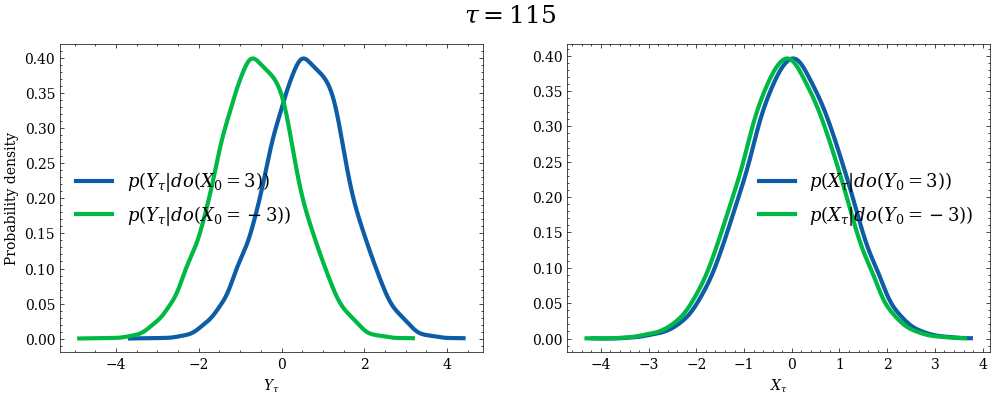

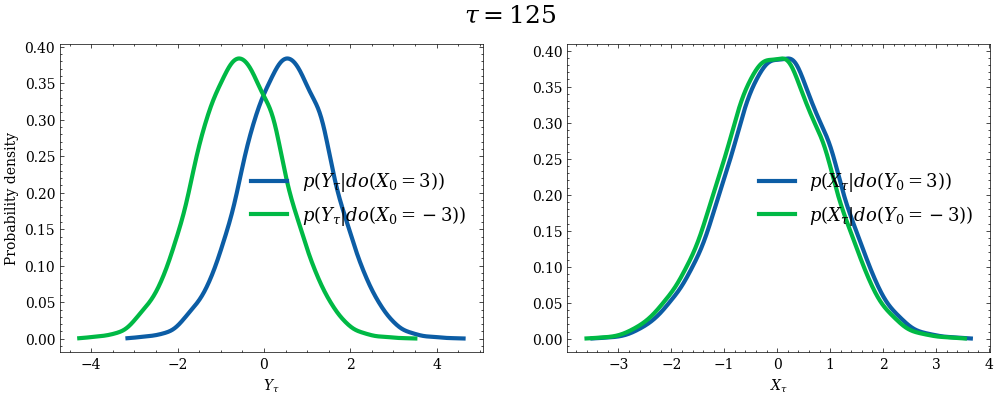

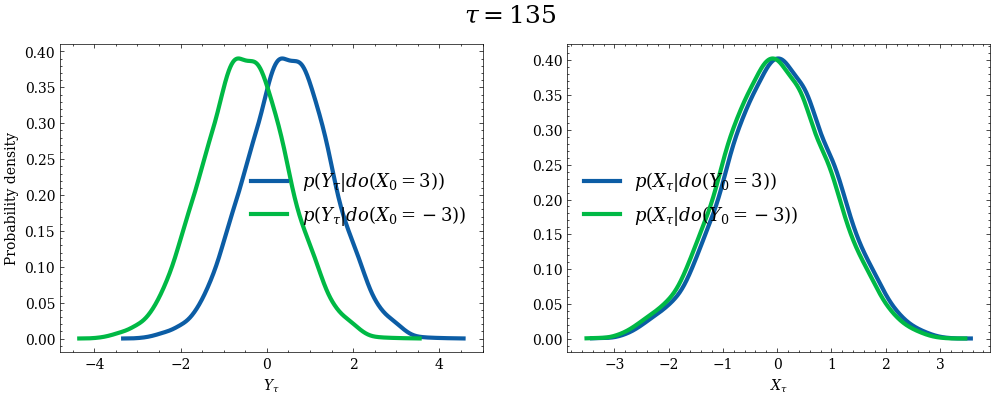

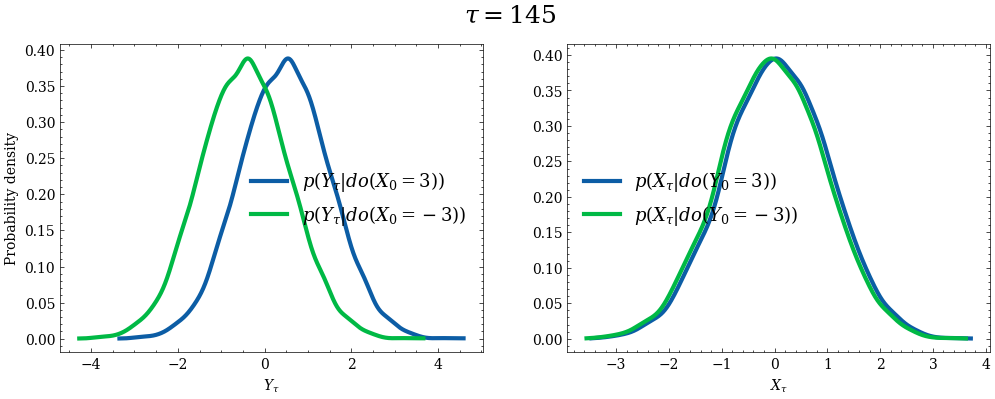

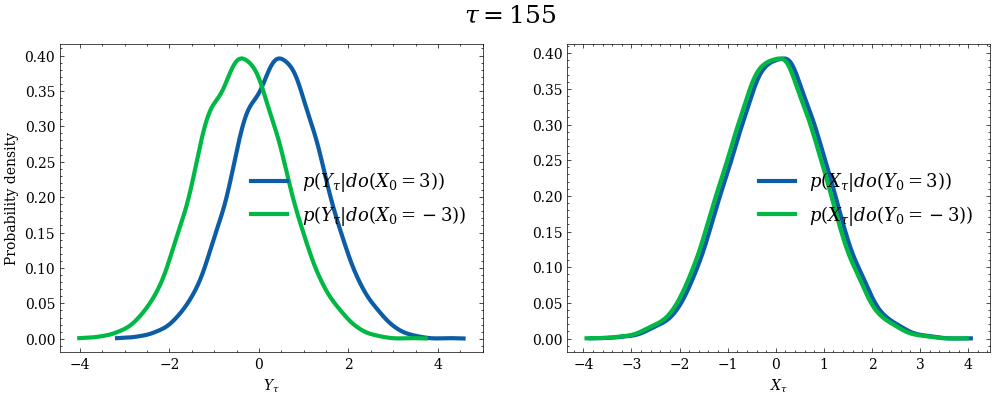

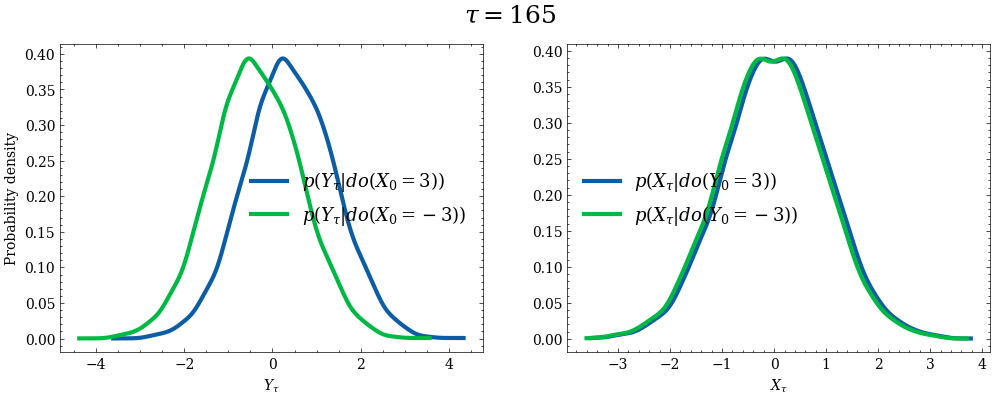

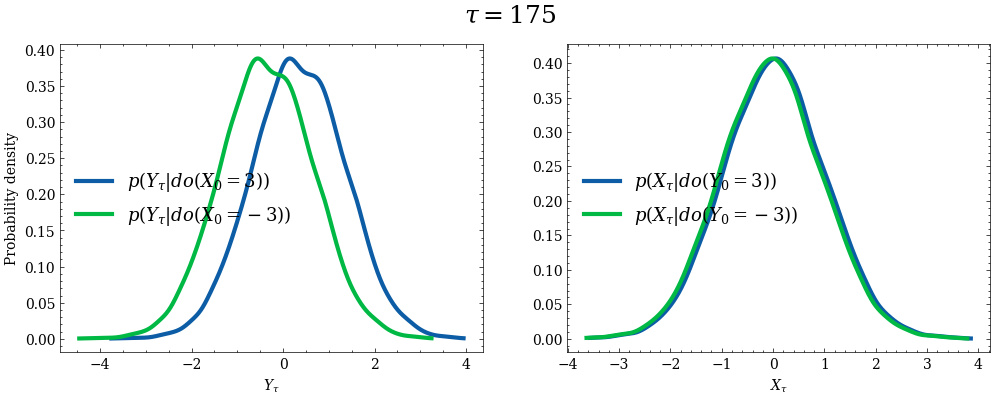

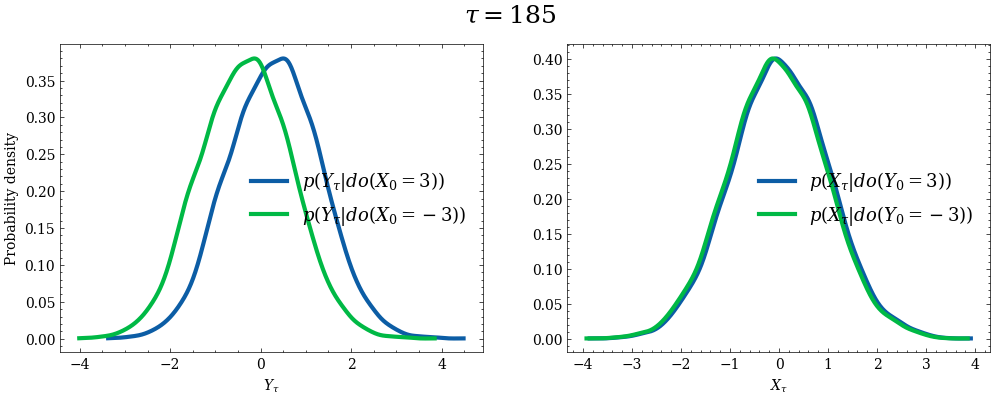

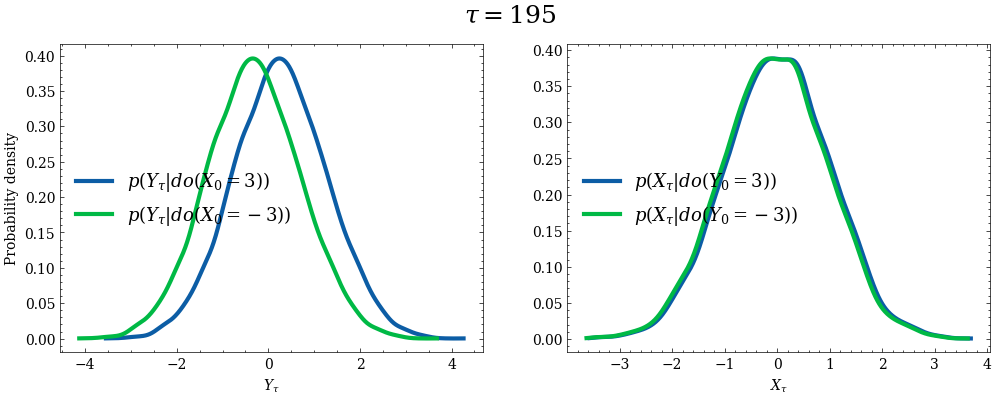

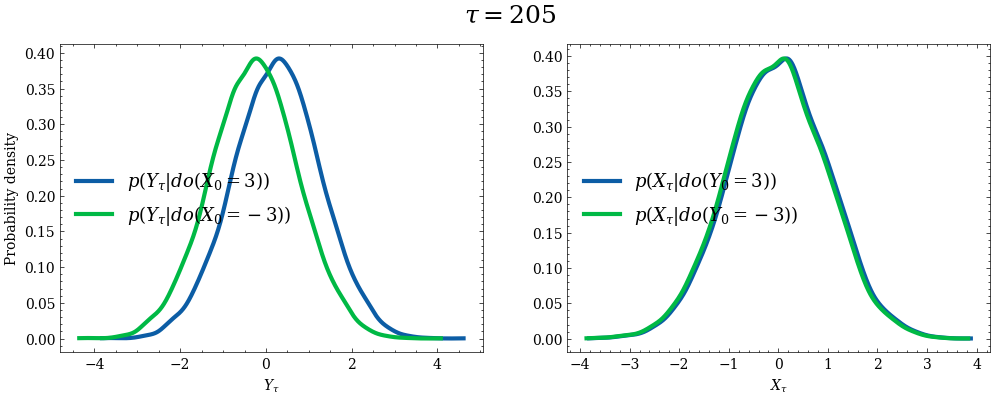

In [5]:
taus = np.concatenate(([1],np.arange(5,215,10,dtype=int)))
bins = 50
linewidth = 3
alpha = 1

for itau, tau in enumerate(taus):
    fig, ax = plt.subplots(1,2,figsize=(12,4))

    #do(X=3)
    kde = gaussian_kde(traj_intxp3[tau,:,1])
    x_range = np.linspace(min(traj_intxp3[tau,:,1]), max(traj_intxp3[tau,:,1]), 1000)
    ax[0].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(Y_{\\tau}|do(X_0=3))$")
    #do(X=-3)
    kde = gaussian_kde(traj_intxm3[tau,:,1])
    x_range = np.linspace(min(traj_intxm3[tau,:,1]), max(traj_intxm3[tau,:,1]), 1000)
    ax[0].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(Y_{\\tau}|do(X_0=-3))$")

    #do(Y=3)
    kde = gaussian_kde(traj_intyp3[tau,:,0])
    x_range = np.linspace(min(traj_intyp3[tau,:,0]), max(traj_intyp3[tau,:,0]), 1000)
    ax[1].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(X_{\\tau}|do(Y_0=3))$")
    #do(Y=-3)
    kde = gaussian_kde(traj_intym3[tau,:,0])
    x_range = np.linspace(min(traj_intym3[tau,:,0]), max(traj_intym3[tau,:,0]), 1000)
    ax[1].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(X_{\\tau}|do(Y_0=-3))$")

    ax[0].set(xlabel="$Y_{\\tau}$", ylabel="Probability density")
    ax[1].set(xlabel="$X_{\\tau}$")
    ax[0].legend(fontsize=13)
    ax[1].legend(fontsize=13)
    plt.suptitle(f"$\\tau = {tau}$", fontsize=18) # multiply by 10 to have same units used in panels E and F
    plt.show()

### Compute KL divergences

In [6]:
def estimate_pdf(data, points):
        kde = gaussian_kde(data)
        return kde(points)

# compute KL divergence
def kl_divergence(X, Y, num_points=1000):
    # Generate a range of values to estimate the PDFs
    min_value = min(np.min(X), np.min(Y))
    max_value = max(np.max(X), np.max(Y))
    points = np.linspace(min_value, max_value, num_points)

    # Estimate PDFs for both X and Y
    pdf_X = estimate_pdf(X, points)
    pdf_Y = estimate_pdf(Y, points)
    
    # Add a small epsilon to avoid division by zero or log(0)
    epsilon = 1e-10
    pdf_X = np.clip(pdf_X, epsilon, None)
    pdf_Y = np.clip(pdf_Y, epsilon, None)
    
    # Step 3: Compute KL divergence
    kl_div = np.sum(pdf_X * np.log(pdf_X / pdf_Y)) * (max_value - min_value) / num_points
    return kl_div

In [11]:
KLs_x = []
KLs_y = []
taus = np.concatenate(([1],np.arange(5,215,10,dtype=int)))

for itau, tau in tqdm(enumerate(taus)):
    # KL[p(Y|do(X=0)) || p(Y|do(X=5))]
    KLs_x.append(kl_divergence(traj_intxp3[tau,:,1],traj_intxm3[tau,:,1]))

    # KL[p(X|do(Y=0)) || p(X|do(Y=5))]
    KLs_y.append(kl_divergence(traj_intyp3[tau,:,0],traj_intym3[tau,:,0]))

with open("/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_with_z_fast_int/pickles_plots/KL_divergences.p","wb") as file:
    #pickle.dump([KLs_x0_x5,KLs_x0_x12,KLs_x5_x12,KLs_y0_y5,KLs_y0_y12,KLs_x0_x5],file)
    pickle.dump([KLs_x,KLs_y],file)

22it [00:41,  1.90s/it]


### Figure for paper

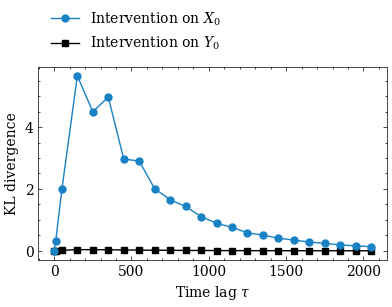

In [12]:
with open("/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_with_z_fast_int/pickles_plots/KL_divergences.p","rb") as file:
    KLs_x, KLs_y = pickle.load(file)

taus = np.concatenate(([0,1],np.arange(5,215,10,dtype=int)))
bins = 50
linewidth = 1
alpha = 1

fig, ax = plt.subplots(1,figsize=(4.5,2.5))

# do(X)
ax.plot(taus, np.append([0],KLs_x),  'o-',  linewidth=1, markersize=5, color=colors[0], label="Intervention on $X_0$", zorder=2)

# do(Y)
ax.plot(taus, np.append([0],KLs_y),  's-',  linewidth=1, markersize=4, color=colors[1], label="Intervention on $Y_0$", zorder=1)
ax.set(xlabel="Time lag $\\tau$", ylabel="KL divergence")
ax.legend(loc=(0.02,1.05))

plt.savefig(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/gaussian_skewed_with_z_fast_int/figures/KL_doX_vs_doY.pdf", dpi=300, bbox_inches="tight")
plt.show()